(ross_recovery)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 恢复定理

```{contents} Contents
:depth: 2
```

## 概述

资产价格具有前瞻性：它们编码了投资者对未来经济状态的预期以及他们对不同风险的估值。

金融领域一个长期存在的问题是：能否仅从观察到的资产价格中*恢复*出投资者所使用的概率分布——即他们的主观信念。

期权价格揭示了**状态价格**；一旦这些价格被无风险贴现因子标准化，所得到的概率就是资产价格在纳入风险调整后所隐含的**风险中性概率**。

这些并不是投资者实际赋予未来世界状态的**自然概率**。

两者之所以不同，是因为风险中性概率将两个不同的对象混合在了一起：市场对未来的真实信念，以及投资者对风险的厌恶。

它们之间的联系是**定价核**，它对自然概率进行重新加权以得出状态价格。

将信念与风险厌恶分离，传统上需要对代表性投资者的偏好做出参数化假设。

{cite:t}`Ross2015` 表明情况并非如此。

罗斯的定理指出，在一个有限状态马尔可夫经济中，状态价格就足够了。

假设阿罗-德布鲁状态价格转移矩阵是无套利且不可约的。

如果定价核还满足一个称为**转移独立性**的结构性约束，那么状态价格就能唯一确定自然概率转移矩阵和转移定价核。

如果关于定价核结构的某些假设成立，那么就不需要历史收益数据或假设的效用函数。

这就是**恢复定理**。

它有几个重要的含义：

* 它展示了当假设成立时，状态价格转移数据如何能够识别市场的前瞻性自然分布
* 它提供了对有效市场假说的检验。
* 它揭示了金融领域的"暗物质"：市场价格中所蕴含的罕见灾难性事件的概率。

本讲座涵盖

* 将状态价格、风险中性概率、定价核和自然概率联系起来的阿罗-德布鲁框架，
* 罗斯的恢复定理及其通过佩龙-弗罗贝尼乌斯定理的证明，
* 一个从模拟的状态价格矩阵中恢复自然分布的实现，以及
* 如何利用期权价格和前向方程来估计转移状态价格，
* 风险中性密度与恢复的自然密度之间的比较。

让我们导入所需的包。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.stats import norm
import matplotlib.cm as cm
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n

## 模型设置

### 阿罗-德布鲁状态价格

考虑一个离散时间、离散状态的经济。

在每个日期，经济处于 $m$ 个状态 $\theta_1, \ldots, \theta_m$ 中的某一个。

一个**阿罗-德布鲁证券**在经济下一期处于状态 $\theta_j$ 时支付 \$1，否则不支付。

用 $p(\theta_i, \theta_j)$ 表示当当前状态为 $\theta_i$ 时，下一期在状态 $\theta_j$ 支付的阿罗-德布鲁证券今天的价格。

将这些价格收集到一个 $m \times m$ 的**状态价格转移矩阵**中

$$
P = [p(\theta_i, \theta_j)]_{i,j=1}^m.
$$

正如在 {doc}`ge_arrow` 中所述，行和给出了状态相关的无风险贴现因子：$\sum_j p(\theta_i, \theta_j) = e^{-r(\theta_i)}$。

这里 $r(\theta_i)$ 是当前状态 $\theta_i$ 中的单期连续复利无风险利率。

更一般地，如果某资产下一期支付 $g(\theta_j)$，那么它在状态 $\theta_i$ 中的价格为

$$
p_g(\theta_i)
    = \sum_j p(\theta_i, \theta_j) g(\theta_j).
$$

令

$$
b(\theta_i) \equiv \sum_j p(\theta_i, \theta_j) = e^{-r(\theta_i)}
$$

为状态 $\theta_i$ 中单期无风险债券的价格。

用这个债券价格标准化阿罗价格，得到**风险中性转移概率**

$$
q^*(\theta_i, \theta_j)
    = \frac{p(\theta_i, \theta_j)}{b(\theta_i)}
    = e^{r(\theta_i)} p(\theta_i, \theta_j).
$$

因此，同样的资产价格可以写成

$$
p_g(\theta_i)
    = b(\theta_i) \sum_j q^*(\theta_i, \theta_j) g(\theta_j)
    = e^{-r(\theta_i)} E_i^*[g(\theta_{t+1})].
$$

这里 $E_i^*$ 表示在 $q^*(\theta_i,\cdot)$ 下的条件期望。

星号标记风险中性测度，或称鞅测度。

将这个单期标准化与动态转移结构分开是有用的。

如果 $Q(\theta_i,\theta_j,T)$ 表示在 $T$ 期内从 $\theta_i$ 转移到 $\theta_j$ 的风险中性概率，且 $0<t<T$ 是一个中间视界，那么马尔可夫前向方程为

$$
Q(\theta_i,\theta_j,T)
    = \sum_k Q(\theta_i,\theta_k,t) Q(\theta_k,\theta_j,T-t).
$$

用矩阵表示，多期风险中性转移矩阵通过矩阵乘法进行复合。

### 定价核

使用在 {doc}`markov_asset` 中研究的随机贴现因子记号以及在 {doc}`ge_arrow` 中使用的阿罗证券记号，定价核 $\phi(\theta_i, \theta_j)$ 通过以下方式将状态价格与自然概率联系起来

$$
p(\theta_i, \theta_j) = \phi(\theta_i, \theta_j) \, f(\theta_i, \theta_j),
$$

其中 $f(\theta_i, \theta_j)$ 是从状态 $\theta_i$ 转移到 $\theta_j$ 的自然（条件）概率。

正如在 {doc}`ge_arrow` 中的代表性主体均衡计算所示，带有贴现因子 $\beta$ 的规范可加分离模型给出

$$
\phi(\theta_i, \theta_j) = \frac{p(\theta_i, \theta_j)}{f(\theta_i, \theta_j)}
    = \frac{\beta U'(c(\theta_j))}{U'(c(\theta_i))}.
$$ (eq:canon_ge)

这个公式有一个特殊结构：核可以写成两个状态特定项之比。

罗斯称这个性质为**转移独立性**。

我们很快会对此进行更多说明。

### 识别挑战

在陈述这个约束之前，看看为什么根本需要它是有帮助的。

给定 $P$，任何满足对每个 $(i,j)$ 都有 $p_{ij} = \phi_{ij} f_{ij}$ 的对 $(\phi, f)$ 都与观察到的状态价格一致。

状态价格矩阵 $P$ 提供了 $m^2$ 个方程。

一个自然转移矩阵 $F$ 贡献了 $m(m-1)$ 个自由项（行和为一），而任意核 $\phi$ 又贡献了另外 $m^2$ 个——总共 $2m^2 - m$ 个未知数，而只有 $m^2$ 个方程。

该系统欠识别 $m^2 - m$ 个参数，因此需要对核施加某种结构性约束，以便分别确定 $\phi$ 和 $f$。

转移独立性约束能够完成这个任务，我们将在下一节看到。

### 转移独立性


```{prf:definition} 转移独立性
:label: def-transition-independence

一个定价核是**转移独立的**，如果在状态空间上存在一个正函数 $h$ 和一个正标量 $\beta$，使得对于从状态 $\theta_i$ 到 $\theta_j$ 的每次转移，

$$
\phi(\theta_i, \theta_j) = \beta \, \frac{h(\theta_j)}{h(\theta_i)}.
$$
```


转移独立性表明核依赖于*终止*状态并按*起始*状态标准化。

在上述代表性主体的完全市场环境中，它在跨期可加分离效用（其中 $h = U'$）下成立。

特别是，这对 {eq}`eq:canon_ge` 成立。

转移独立性之所以有帮助，是因为它把 $\phi$ 的所有 $m^2$ 个项绑定在一起：一旦知道了 $m$ 个状态特定值，整个核就被确定了。

因此它将 $\phi$ 从 $m^2$ 个自由项减少到 $m$ 个，从而系统变得恰好可识别。

在转移独立性下，状态价格方程变为

$$
p(\theta_i, \theta_j) = \beta \, \frac{h(\theta_j)}{h(\theta_i)} \,
    f(\theta_i, \theta_j).
$$

用矩阵表示，定义对角矩阵 $D$，其中 $D_{ii} = h(\theta_i)/\beta$，

$$
DP = \beta F D,
$$

或等价地，

$$
F = \frac{1}{\beta} D P D^{-1}.
$$

## 恢复定理

### 化归为特征值问题

由于 $F$ 是随机矩阵，其行和为一：$F e = e$，其中 $e$ 是全为一的向量。

代入 $F$ 的表达式：

$$
\frac{1}{\beta} D P D^{-1} e = e
\quad \Longrightarrow \quad
P z = \beta z, \quad z \equiv D^{-1} e.
$$

这是一个**特征值问题**，我们寻求满足 $Pz = \beta z$ 的正向量 $z$ 和标量 $\beta$。

原则上 $P$ 的每一个特征值-特征向量对都是一个形式解，但只有具有严格正特征向量的那个在经济上是有效的：$D_{ii} = 1/z_i$ 必须为正（因此 $z_i > 0$），并且 $F$ 必须具有非负项。

佩龙-弗罗贝尼乌斯定理保证恰好存在一个这样的对。

```{prf:theorem} 佩龙-弗罗贝尼乌斯
:label: thm-perron-frobenius

如果 $A$ 是一个非负不可约矩阵，那么

1. $A$ 有一个等于其谱半径的正实特征值 $r$（佩龙根）。
2. 存在一个严格正的特征向量 $z \gg 0$，满足 $Az = rz$，在缩放意义下唯一。
3. 没有其他特征向量是严格正的。
```

当矩阵是非本原的时，其他特征值可以具有相同的模，但严格正的特征向量在缩放意义下是唯一的。

详见 {cite:t}`Sargent_Stachurski_2024` 的第1.2.3节。

另见 {doc}`intro:eigen_II` 中的完整陈述。

应用于恢复问题：佩龙根是 $\beta$（主观贴现因子），而佩龙向量 $z$ 通过 $D_{ii} = 1/z_i$ 确定 $D$。


### 罗斯的恢复定理

定理中的三个假设各自承担着特定的角色。

假设阿罗-德布鲁状态价格已被识别，无套利保证 $P$ 具有非负项，并且状态价格编码了一个明确定义的定价测度。

不可约性确保经济没有被分割成互不相连的子经济——如果没有它，佩龙-弗罗贝尼乌斯定理会给出多个候选特征向量，恢复就会失效。

转移独立性是关键的经济约束。

它表明定价核可以分解为 $\beta h(\theta_j)/h(\theta_i)$，因此整个核由一个单一向量 $h$（或等价地 $z$）确定。

考虑到这些，恢复定理便由佩龙-弗罗贝尼乌斯定理得出。


```{prf:theorem} 恢复定理
:label: thm-ross-recovery

假设价格不提供套利机会，状态价格转移矩阵 $P$ 是不可约的，并且定价核是转移独立的。

那么恢复问题存在一个正解 $(\beta, z, F)$，其中 $z$ 在标准化意义下唯一，并且所隐含的自然概率转移矩阵 $F$ 和转移定价核是唯一的。
```

```{prf:proof}
因为 $P$ 是非负且不可约的，佩龙-弗罗贝尼乌斯定理给出一个唯一的正特征向量 $z \gg 0$，其正特征值 $\lambda > 0$ 满足 $Pz = \lambda z$。

设

$$
\beta = \lambda, \qquad D_{ii} = \frac{1}{z_i},
$$

自然概率转移矩阵唯一地恢复为

$$
f_{ij} = \frac{1}{\beta} \frac{z_j}{z_i} \, p_{ij}.
$$

为确认 $F$ 是随机矩阵，注意所有项都是非负的（因为 $p_{ij} \geq 0$ 且 $z_i, z_j > 0$），并且

$$
\sum_j f_{ij}
= \frac{1}{\beta z_i} \sum_j z_j \, p_{ij}
= \frac{[Pz]_i}{\beta z_i}
= \frac{\beta z_i}{\beta z_i} = 1.
$$

唯一性由佩龙-弗罗贝尼乌斯特征向量的唯一性得出。
```

### 从特征向量得到定价核

恢复的转移核值为

$$
\phi(\theta_i, \theta_j) = \beta \frac{z_i}{z_j},
\qquad h(\theta_i) = \frac{\beta}{z_i},
$$

其中 $h(\theta_i) = \beta/z_i$ 由 $D_{ii} = h(\theta_i)/\beta = 1/z_i$ 得出。

区分**完整转移核** $\phi_{ij} = \beta z_i/z_j$（它依赖于起始状态和目标状态）和**相对核成分** $1/z_j$（它仅依赖于目标状态）是有用的。

罗斯的表I报告了目标状态形状 $1/z_j$，经标准化使得中间状态等于一。

具有高 $z_j$ 的目标状态具有*低*核值：对于固定的起始状态 $i$，核 $\beta z_i/z_j$ 随 $z_j$ 递减。

当 $h$ 表示边际效用且状态按消费或收益排序时，较大的 $z_j$ 对应较低的边际效用——即"好时光"，它们需要较少的保险，因此每单位自然概率获得较少的定价权重。

同样的特征向量论证还给出一个有用的极限情形。

如果单期债券价格在每个当前状态中都相同，那么全一向量已经是佩龙向量，因此恢复没有需要执行的状态相关的测度变换。


```{prf:corollary}
:label: cor-risk-neutral-recovery

如果无风险利率在所有状态中都相同（对某个标量 $b$ 有 $Pe = b e$），那么与恢复一致的唯一自然分布就是风险中性（鞅）分布本身：$F = (1/b) P$。
```

```{prf:proof}
当 $Pe = b e$ 时，全一向量 $e$ 是特征值为 $b$ 的佩龙特征向量。

由佩龙-弗罗贝尼乌斯定理的唯一性部分，$z = e$（在缩放意义下）且 $\beta = b$。

设 $z = e$ 得 $D = I$，因此

$$
F = \frac{1}{\beta} D P D^{-1} = \frac{1}{b} P. \qquad \square
$$
```

(ross-recovery-single-crossing)=
### 单交叉与风险溢价

罗斯还使用代表性主体公式直接比较自然密度和风险中性密度。

对于固定的当前状态 $\theta_i$，

$$
\frac{q^*(\theta_i,\theta_j)}{f(\theta_i,\theta_j)}
    = e^{r(\theta_i)} \phi(\theta_i,\theta_j)
    = e^{r(\theta_i)} \beta
      \frac{U'(c(\theta_j))}{U'(c(\theta_i))}.
$$ (eq:rn-natural-ratio)

如果 $U'$ 随消费递减，那么 {eq}`eq:rn-natural-ratio` 中的比率随下一期消费 $c(\theta_j)$ 递减。

由于 $q^*(\theta_i,\cdot)$ 和 $f(\theta_i,\cdot)$ 的积分都为一，存在一个由以下方程定义的交叉点 $v$

$$
e^{r(\theta_i)} \beta U'(v) = U'(c(\theta_i)).
$$

在 $v$ 以下，风险中性概率超过自然概率；在 $v$ 以上，自然概率超过风险中性概率。

因此自然消费分布一阶随机占优于风险中性分布。

在一个终端消费即市场收益的单期模型中，这也给出了正的市场风险溢价。

设 $R$ 表示自然律下的市场收益，设 $R^*$ 表示风险中性律下的同一收益，设 $R_f$ 表示同一单期单位下的无风险收益。

随机占优结果可以表示为

$$
R^* \sim R - Z + \epsilon,
$$

其中 $Z \geq 0$ 捕获风险调整所引起的向下移动，$\epsilon$ 是满足 $E[\epsilon \mid R-Z]=0$ 的残差。

取期望得

$$
E[R] = R_f + E[Z] > R_f.
$$

## 数值示例

我们现在从数值上演示恢复定理。

### 构建一个有限状态示例

我们直接在一个有限的对数收益状态网格 $s_1, \ldots, s_m$ 上构建经济。

在这个网格上，我们选择三个基本要素：

1. 一个行随机的不可约自然转移矩阵 $F$，
2. 一个主观贴现因子 $\beta = e^{-\rho T}$，以及
3. 一个 CRRA 转移定价核 $\phi_{ij} = \beta e^{-\gamma(s_j-s_i)}$。

状态价格矩阵然后由以下构造

$$
p_{ij} = \phi_{ij} f_{ij}.
$$

这意味着恢复定理的假设在构造上成立：$P$ 是非负的，$F$ 是一个马尔可夫转移矩阵，并且核是转移独立的，$z_i \propto e^{\gamma s_i}$。

为使示例接近罗斯的第IV节，我们选择 $F$ 具有对数正态形状的行。

连续基准是带有 CRRA 效用的对数正态收益：

$$
U(S_T) = \frac{S_T^{1-\gamma}}{1-\gamma},
\qquad
S_T = S_0
      \exp\!\left((\mu-\tfrac{1}{2}\sigma^2)T
                 + \sigma \sqrt{T} \xi\right),
$$

其中 $\xi \sim N(0,1)$，$\mu$ 是预期增长率参数，$\sigma$ 是波动率，$T$ 是视界，$\gamma$ 是 CRRA 系数，$\rho$ 是连续复利主观贴现率。

$T$ 期定价核为

$$
\phi_T
    = e^{-\rho T}\left(\frac{S_T}{S_0}\right)^{-\gamma}.
$$

等价地，如果 $s=\log S_0$ 且 $s_T=\log S_T$，那么关于未来对数状态 $s_T$ 的状态价格密度为

$$
p_T(s,s_T)
    = e^{-\rho T} e^{-\gamma(s_T-s)}
      \frac{1}{\sigma \sqrt{T}}
      n\!\left(
        \frac{s_T-s-(\mu-\frac{1}{2}\sigma^2)T}
             {\sigma \sqrt{T}}
      \right),
$$

其中 $n$ 是标准正态密度。

因此自然对数收益满足

$$
\log(S_T/S_0) \sim \mathcal{N}\!\left((\mu - \tfrac{1}{2}\sigma^2)T, \sigma^2 T\right).
$$

遵循罗斯的表I，我们在一个有限的状态网格上表示分布。

这个示例受罗斯启发，而非罗斯表I的精确重现。

罗斯的表I使用固定的未来收益分布，因此其 $F$ 的行是相同的。

这里同样的 CRRA/对数正态定价逻辑被嵌入到一个有限马尔可夫转移矩阵中，其行随当前状态而移动。

罗斯使用从 $-5$ 到 $+5$ 个标准差的状态；我们在下面使用相同的范围。

截断是有限状态模型的一个基本组成部分：正是它将示例带入佩龙-弗罗贝尼乌斯设定中。

在无界连续对数正态增长模型中，罗斯表明恢复不是唯一的。

在有限网格上，自然转移概率和状态价格为

$$
f_{ij} \propto
    n\!\left(\frac{s_j - s_i - (\mu - \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}\right)
    \Delta s,
\qquad
p_{ij} = e^{-\rho T} e^{-\gamma(s_j - s_i)} f_{ij},
$$

其中 $s_i = \ln S_i$，$s_j = \ln S_j$，$n(\cdot)$ 是标准正态密度，离散化概率 $f_{ij}$ 按行标准化。

下一个代码单元构造这个有限网格并构建 $P$。

In [2]:
def build_state_price_matrix(μ, σ, γ, ρ, T=1.0, n_states=11, n_σ=5):
    """构建一个离散化的对数正态/CRRA状态价格矩阵。"""
    states = np.linspace(-n_σ * σ * np.sqrt(T),
                          n_σ * σ * np.sqrt(T),
                          n_states)
    ds = states[1] - states[0]

    m = n_states
    P = np.zeros((m, m))
    F = np.zeros((m, m))

    drift = (μ - 0.5 * σ**2) * T

    # 首先在有界网格上构建一个行随机的自然转移矩阵
    for i in range(m):
        s_i = states[i]
        for j in range(m):
            s_j = states[j]
            log_return = s_j - s_i
            F[i, j] = norm.pdf(log_return, loc=drift,
                               scale=σ * np.sqrt(T)) * ds

        F[i] = F[i] / F[i].sum()

        # 将每个阿罗债权定价为自然概率乘以CRRA核
        for j in range(m):
            log_return = states[j] - s_i
            kernel = np.exp(-ρ * T) * np.exp(-γ * log_return)
            P[i, j] = kernel * F[i, j]

    return P, states

现在选择一个校准并构建状态价格矩阵。

In [3]:
μ = 0.08    # 8%年预期收益
σ = 0.20    # 20%年波动率
γ = 3.0     # CRRA系数
ρ = 0.02    # 2%年连续贴现率
T = 1.0     # 一年视界

P, states = build_state_price_matrix(μ, σ, γ, ρ, T,
                                     n_states=11, n_σ=5)

print("State-price row sums:")
print(np.round(P.sum(axis=1), 4))
print(f"Middle-state risk-free rate: {-np.log(P[5].sum()):.4f}")

State-price row sums:
[0.7154 0.9046 0.9713 0.9798 0.9802 0.9802 0.9802 0.9806 0.9892 1.0621
 1.3429]
Middle-state risk-free rate: 0.0200


行和是每个当前状态下模型隐含的单期债券价格。

它们在边界附近变化，因为有限网格截断并重新标准化了条件转移概率。

### 应用恢复定理

恢复定理要求计算 $P$ 的**佩龙特征向量**。

In [4]:
def recover_natural_distribution(P, tol=1e-10):
    """
    从状态价格中恢复自然概率和相对定价核。
    """

    m = P.shape[0]

    eigenvalues, eigenvectors = eig(P)
    eigenvalues = np.real_if_close(eigenvalues, tol=1000)
    eigenvectors = np.real_if_close(eigenvectors, tol=1000)

    # 罗斯恢复使用佩龙根及其严格正的特征向量
    real_mask = np.isreal(eigenvalues)
    real_eigenvalues = np.asarray(
        eigenvalues[real_mask].real, dtype=float)
    real_eigenvectors = np.asarray(
        eigenvectors[:, real_mask].real, dtype=float)

    order = np.argsort(real_eigenvalues)[::-1]

    for idx in order:
        β_candidate = real_eigenvalues[idx]
        z_candidate = real_eigenvectors[:, idx]

        if np.mean(z_candidate) < 0:
            z_candidate = -z_candidate

        if β_candidate > 0 and np.all(z_candidate > tol):
            β_recovered = β_candidate
            z = z_candidate
            break
    else:
        raise ValueError("No strictly positive real eigenvector found")

    z = z / z[m // 2]

    D = np.diag(1.0 / z)
    D_inv = np.diag(z)

    # 将状态价格转换为概率
    F = (1.0 / β_recovered) * D @ P @ D_inv

    min_entry = F.min()
    row_sum_error = np.max(np.abs(F.sum(axis=1) - 1.0))

    if min_entry < -tol:
        raise ValueError(f"Recovered F has negative entries: min={min_entry}")

    if row_sum_error > 1e-8:
        raise ValueError(
            f"Recovered F row sums are not one: max error={row_sum_error}"
        )

    # 相对于中间状态标准化的核
    φ_relative = 1.0 / z

    return F, z, β_recovered, φ_relative

佩龙向量还恢复了定价核的形状。

罗斯的表I以中间状态标准化为一的方式报告这个形状，在我们的标准化 $z_{\text{mid}}=1$ 下即为 $1/z_j$。

In [5]:
F, z, β_rec, φ_relative = recover_natural_distribution(P)

print("Ross-normalized kernel 1/z (middle state = 1):")
print(np.round(φ_relative, 4))

Ross-normalized kernel 1/z (middle state = 1):
[20.0855 11.0232  6.0496  3.3201  1.8221  1.      0.5488  0.3012  0.1653
  0.0907  0.0498]


因为我们知道用于构造 $P$ 的数据生成自然转移矩阵，所以我们可以验证恢复在此模拟中有效。

In [6]:
def true_lognormal_transition_matrix(states, μ, σ, T):
    """
    构造模拟中使用的有界网格自然转移矩阵。
    """
    m = len(states)
    ds = states[1] - states[0]
    drift = (μ - 0.5 * σ**2) * T
    F_true = np.zeros((m, m))

    for i in range(m):
        log_returns = states - states[i]
        F_true[i] = norm.pdf(log_returns, loc=drift,
                             scale=σ * np.sqrt(T)) * ds
        F_true[i] = F_true[i] / F_true[i].sum()

    return F_true


F_true = true_lognormal_transition_matrix(states, μ, σ, T)
P_reconstructed = β_rec * (z[:, None] / z[None, :]) * F

print("Recovery numerical checks")
print(f"max |F - true F| = {np.max(np.abs(F - F_true)):.2e}")
print(f"max |P - recovered kernel times F| = "
      f"{np.max(np.abs(P - P_reconstructed)):.2e}")

Recovery numerical checks
max |F - true F| = 2.57e-14
max |P - recovered kernel times F| = 1.11e-16


确实，差异处于数值舍入误差的水平。

## 自然分布与风险中性分布

{cite:t}`Ross2015` 的一个关键洞见是，自然分布可以系统性地不同于风险中性分布。

在这个 CRRA 示例中，状态从低收益到高收益排序，{ref}`ross-recovery-single-crossing` 中的单交叉论证意味着自然边缘密度**一阶随机占优**于风险中性密度：自然分布的累积分布函数位于风险中性分布累积分布函数的*下方*。

因为定价核是递减的（投资者害怕不好的结果），风险中性概率相对于自然测度过度加权坏状态而低估好状态。

我们首先绘制自然分布与风险中性分布以及恢复的相对定价核

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


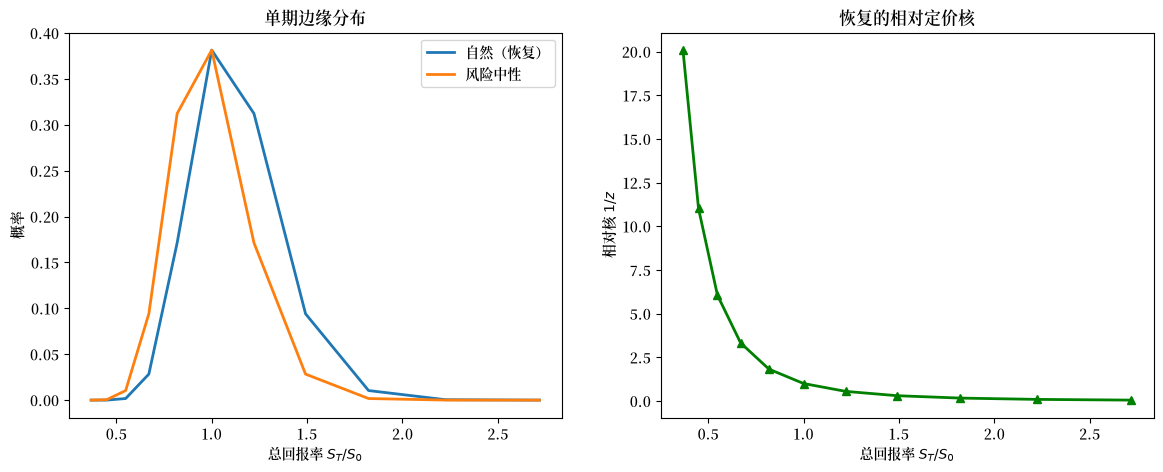

In [7]:
mid = len(states) // 2

row_sums = P.sum(axis=1, keepdims=True)

# 用每个状态下的单期无风险债券价格标准化阿罗价格
Q_rn = P / row_sums

f_nat = F[mid, :]
f_rn = Q_rn[mid, :]

gross_returns = np.exp(states)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(gross_returns, f_nat, label='自然（恢复）', lw=2)
axes[0].plot(gross_returns, f_rn, label='风险中性', lw=2)
axes[0].set_xlabel('总回报率 $S_T / S_0$')
axes[0].set_ylabel('概率')
axes[0].set_title('单期边缘分布')
axes[0].legend()

axes[1].plot(gross_returns, φ_relative, 'g-^', lw=2)
axes[1].set_xlabel('总回报率 $S_T / S_0$')
axes[1].set_ylabel('相对核 $1/z$')
axes[1].set_title('恢复的相对定价核')
plt.show()

累积分布函数清楚地显示了一阶随机占优

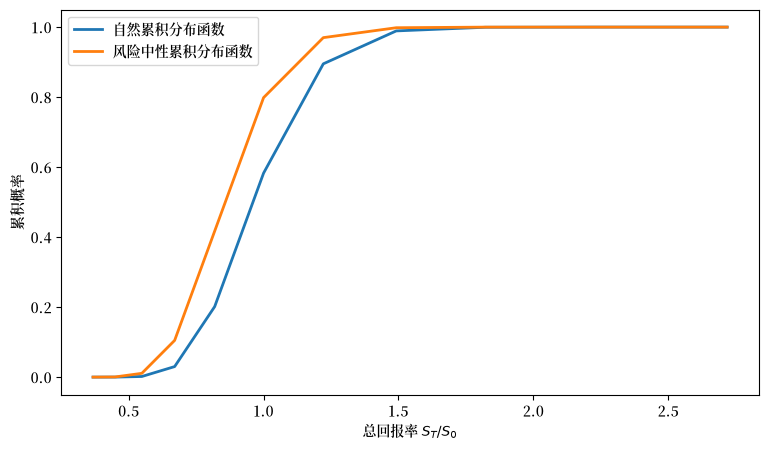

Natural CDF <= Risk-neutral CDF at all states: True


In [8]:
cdf_nat = np.cumsum(f_nat)
cdf_rn = np.cumsum(f_rn)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(gross_returns, cdf_nat, lw=2, label='自然累积分布函数')
ax.plot(gross_returns, cdf_rn, lw=2, label='风险中性累积分布函数')
ax.set_xlabel('总回报率 $S_T / S_0$')
ax.set_ylabel('累积概率')
ax.legend()
plt.show()

print(f"Natural CDF <= Risk-neutral CDF at all states: "
      f"{np.all(cdf_nat <= cdf_rn + 1e-10)}")

两个累积分布函数之间的差距是由定价核的斜率产生的。

在 CRRA 基准中，这个斜率由风险厌恶系数 $\gamma$ 控制。

接下来我们变化 $\gamma$ 以观察恢复的核和自然/风险中性楔子如何变化。

## 风险厌恶的影响

定价核的形状，以及由此产生的自然概率与风险中性概率之间的差距，取决于风险厌恶系数 $\gamma$。

我们通过绘制相对定价核 $1/z$ 以及自然密度和风险中性密度之间的差距（对于一系列 $\gamma$ 值）来说明这一点。

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


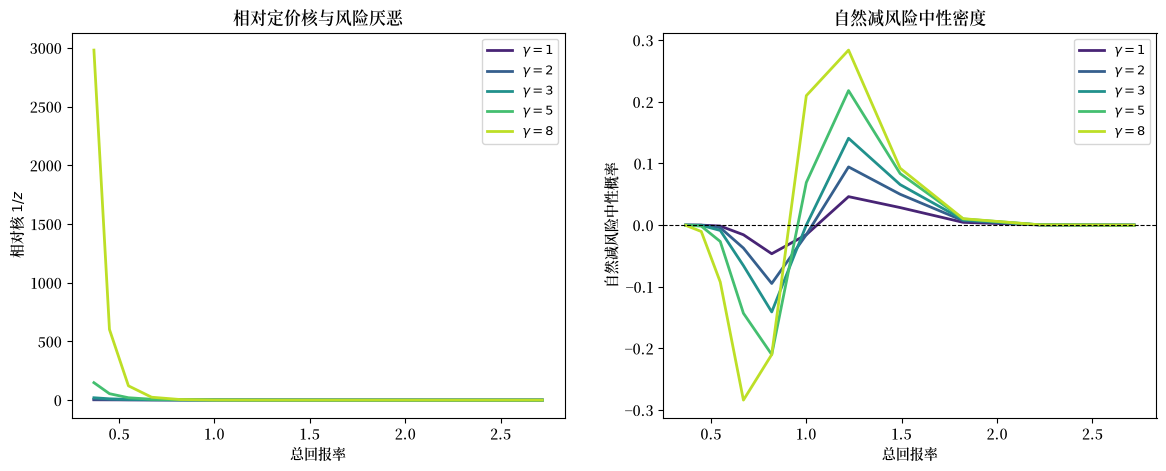

In [9]:
γs = [1.0, 2.0, 3.0, 5.0, 8.0]
colors = cm.viridis(np.linspace(0.1, 0.9, len(γs)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for γ_val, color in zip(γs, colors):
    P_g, states_g = build_state_price_matrix(μ, σ, γ_val, ρ, T)
    F_g, z_g, β_g, φ_relative_g = recover_natural_distribution(P_g)
    mid_g = len(states_g) // 2

    f_nat_g = F_g[mid_g, :]
    row_sum = P_g[mid_g].sum()
    f_rn_g = P_g[mid_g] / row_sum

    gross = np.exp(states_g)

    axes[0].plot(gross, φ_relative_g, color=color, lw=2,
                 label=f'$\\gamma={γ_val:.0f}$')
    axes[1].plot(gross, f_nat_g - f_rn_g, color=color, lw=2,
                 label=f'$\\gamma={γ_val:.0f}$')

axes[0].set_xlabel('总回报率')
axes[0].set_ylabel('相对核 $1/z$')
axes[0].set_title('相对定价核与风险厌恶')
axes[0].legend(fontsize=9)

axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set_xlabel('总回报率')
axes[1].set_ylabel('自然减风险中性概率')
axes[1].set_title('自然减风险中性密度')
axes[1].legend(fontsize=9)

plt.show()

因为状态从低收益到高收益排序，这些图显示了 {ref}`ross-recovery-single-crossing` 中讨论的单交叉性质：对于低于某个阈值 $v$ 的收益，风险中性概率超过自然概率；在 $v$ 以上，自然概率占优。

较高的 $\gamma$ 放大了这个楔子。

## 恢复贴现率

恢复定理的一个有用副产品是*恢复的主观贴现因子* $\beta$，它等于 $P$ 的佩龙-弗罗贝尼乌斯特征值。

如果视界为 $T$，则对应的连续复利主观贴现率为

$$
\rho = -\frac{\log \beta}{T}.
$$

在下面的数值示例中，$T=1$，因此这简化为 $\rho = -\log \beta$。

{cite:t}`Ross2015` 的推论1指出，$\beta$ 的上界是最大的状态相关单期贴现因子——等价地，是 $P$ 的最大行和：

$$
\beta \leq \max_i \sum_j p(\theta_i, \theta_j).
$$

在网格上扫描真实的 $\rho$ 并报告恢复值以及恢复误差，确认了特征值计算准确地确定了 $\beta$：

In [10]:
true_ρs = np.linspace(0.00, 0.06, 13)
recovered_ρs = np.empty_like(true_ρs)

for k, rho in enumerate(true_ρs):
    P_d, _ = build_state_price_matrix(μ, σ, γ=3.0, ρ=rho, T=1.0)
    _, _, β_d, _ = recover_natural_distribution(P_d)
    recovered_ρs[k] = -np.log(β_d)

print(
    f"max |true ρ - recovered ρ| = {np.max(np.abs(true_ρs - recovered_ρs)):.2e}")
np.column_stack([true_ρs, recovered_ρs])

max |true ρ - recovered ρ| = 2.23e-15


array([[ 0.00000000e+00, -2.22044605e-16],
       [ 5.00000000e-03,  5.00000000e-03],
       [ 1.00000000e-02,  1.00000000e-02],
       [ 1.50000000e-02,  1.50000000e-02],
       [ 2.00000000e-02,  2.00000000e-02],
       [ 2.50000000e-02,  2.50000000e-02],
       [ 3.00000000e-02,  3.00000000e-02],
       [ 3.50000000e-02,  3.50000000e-02],
       [ 4.00000000e-02,  4.00000000e-02],
       [ 4.50000000e-02,  4.50000000e-02],
       [ 5.00000000e-02,  5.00000000e-02],
       [ 5.50000000e-02,  5.50000000e-02],
       [ 6.00000000e-02,  6.00000000e-02]])

## 尾部风险：灾难的自然概率与风险中性概率

恢复定理最引人注目的应用之一是它能够将市场恢复的灾难自然概率与附加于这些灾难的风险溢价分离开来。

{cite:t}`barro2006rare` 和 {cite:t}`MehraPrescott1985` 讨论了罕见灾难如何可能解释股权溢价之谜。

大幅下跌的风险中性概率之所以升高，既是因为（a）市场对此类事件赋予了高的自然概率，也是因为（b）定价核上调了坏结果的权重。

罗斯的恢复机制让我们能够分解这两种力量。

下一个代码单元绘制从中间状态出发，在恢复的自然测度和风险中性测度下的左尾概率，因此曲线之间的差距分离出了定价核对崩盘概率的贡献。

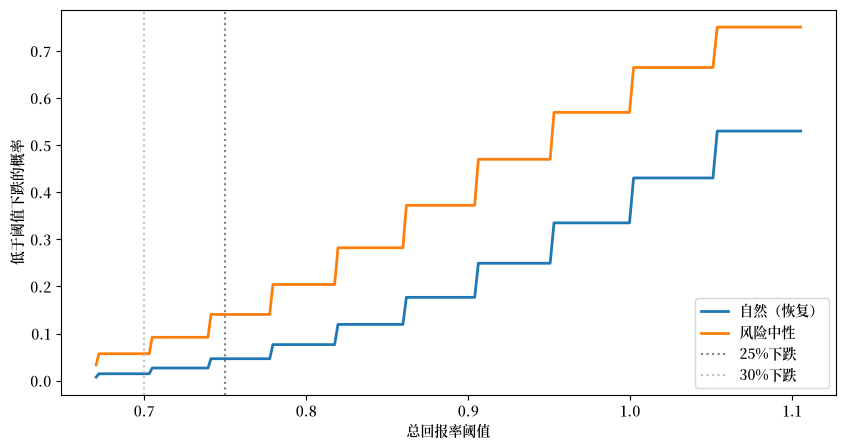

In [11]:
thresholds = np.linspace(-0.40, 0.10, 200)

def tail_prob(f_dist, states, threshold):
    """对数收益的左尾概率。"""
    return float(np.sum(f_dist[states <= threshold]))

P_base, states_base = build_state_price_matrix(
    μ, σ, γ=3.0, ρ=0.02, T=1.0,
    n_states=41, n_σ=5)
F_base, z_base, β_base, φ_relative_base = recover_natural_distribution(P_base)

mid_b = len(states_base) // 2
f_nat_base = F_base[mid_b]
f_rn_base = P_base[mid_b] / P_base[mid_b].sum()

prob_nat = [tail_prob(f_nat_base, states_base, t) for t in thresholds]
prob_rn = [tail_prob(f_rn_base, states_base, t) for t in thresholds]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.exp(thresholds), prob_nat, lw=2, label='自然（恢复）')
ax.plot(np.exp(thresholds), prob_rn, lw=2, label='风险中性')
ax.set_xlabel('总回报率阈值')
ax.set_ylabel('低于阈值下跌的概率')
ax.axvline(x=0.75, color='gray', ls=':', lw=1.5, label='25%下跌')
ax.axvline(x=0.70, color='silver', ls=':', lw=1.5, label='30%下跌')
ax.legend()
plt.show()

这是一个说明罗斯分解的模拟。

风险中性密度对大幅下跌赋予的概率高于恢复的自然密度。

在这个 CRRA 模拟中，增加风险厌恶会使风险中性崩盘概率比恢复的自然崩盘概率上升得更快。

我们将在 {ref}`rt_ex3` 中进行更多说明。

## 从期权价格到转移价格

上面的数值示例从一个已知的状态价格转移矩阵 $P$ 开始。

在经验上，罗斯从更早一步开始：期权价格揭示了从当前状态出发在不同到期日的状态价格密度，而转移矩阵必须从这些逐个到期日的状态价格中推断出来。

设 $C(K,T)$ 为行权价为 $K$、到期日为 $T$ 的看涨期权的价格。

如果 $p(S,T)$ 是终端指数水平 $S$ 的状态价格密度，那么

$$
C(K,T)
    = \int_K^\infty (S-K) p(S,T) \, dS.
$$

对行权价求两次微分给出 {cite:t}`BreedenLitzenberger1978` 公式

$$
p(K,T) = \frac{\partial^2 C(K,T)}{\partial K^2}.
$$

在对行权价和到期日进行离散化后，设

$$
p_t(c) = \big(p_t(c,1), \ldots, p_t(c,m)\big)
$$

为从今天状态 $c$ 观察到的视界 $t$ 处的状态价格向量。

这里 $c$ 索引当前状态，$t$ 计数离散到期步数。

第一个单期向量 $p_1(c)$ 识别对应于当前状态 $c$ 的 $P$ 的行，提供 $m$ 个方程。

如果单期状态价格转移矩阵 $P$ 是时间齐次的，那么这些向量满足前向递归

$$
p_{t+1}(c) = p_t(c) P,
\qquad t=1,\ldots,m-1.
$$

按分量表示，

$$
p_{t+1}(c,j) = \sum_k p_t(c,k) p(k,j).
$$

其余 $m-1$ 个前向方程 $p_{t+1}(c)=p_t(c)P$，每个有 $m$ 个分量，提供其余的 $m(m-1)$ 个方程。

这些方程合在一起为 $m^2$ 个转移价格 $p(k,j)$ 给出 $m^2$ 个方程。

在实践中，这一步在数值上很微妙，因为期权价格公式中的二阶导数会放大测量误差，并且可能需要正性或单峰性等额外的形状约束来获得一个合理的转移矩阵。

## 检验有效市场

在恢复定理的假设下，恢复的定价核也可以用来检验市场有效性。

如果一个交易策略有非常高的夏普比率，那么某个定价核必须足够波动才能对该收益定价。

汉森-贾格纳坦界 {cite}`Hansen_Jagannathan_1991` 指出，对于任何均值为 $\mu_\text{excess}$、标准差为 $\sigma_\text{asset}$ 的超额收益，

$$
\frac{|\mu_\text{excess}|}{\sigma_\text{asset}} \leq e^{rT}\, \sigma(M),
$$

其中 $M$ 是单期随机贴现因子，$r$ 是视界 $T$ 上的连续复利无风险利率。

罗斯的观点是，恢复给出了相关波动率 $\sigma(M)$ 的估计。

因此它给出了基于恢复中使用的相同股市信息的任何策略的夏普比率的上界。

如果这样的策略的夏普比率高于该界限，那么在恢复定理的假设下，它就过于盈利而无法与有效性一致。

同样的逻辑给出了收益可预测性的界限。

假设超额收益分解为

$$
x_{t+1} = \mu(I_t) + \epsilon_{t+1},
$$

其中 $I_t$ 是股市信息集，$\epsilon_{t+1}$ 从 $I_t$ 无法预测。

那么基于 $I_t$ 的预测回归的 $R^2$ 上界为恢复核的方差：

$$
R^2 \leq e^{2rT} \, \sigma^2(M).
$$

只有投影到这个信息集上的核成分是相关的。

向候选定价核添加不相关的噪声会提高其方差，但不会为来自股市信息的更强收益可预测性提供依据。

## 局限性与扩展

恢复定理是一个了不起的理论结果，但在实践中有几个需要注意的地方。

*有限状态空间：*

罗斯的定理是针对有限状态不可约马尔可夫链证明的；有界连续状态恢复需要 {doc}`misspecified_recovery` 中的额外结果。

在连续、无界的状态空间中（例如对数正态扩散），唯一性失效，因为任何指数 $e^{\alpha x}$ 都满足特征方程。

为看清这个问题，考虑上面的连续对数正态增长状态价格密度。

佩龙-弗罗贝尼乌斯问题的自然连续空间类比是

$$
\int p_T(s,y) v(y) \, dy = \lambda v(s).
$$

这里 $y$ 是一个可能的未来对数状态，$v$ 是一个候选正特征函数，$\lambda$ 是它的特征值。

对于每个实数 $\alpha$，指数函数 $v_\alpha(s)=e^{\alpha s}$ 求解这个方程，特征值为

$$
\lambda(\alpha)
    =
    \exp\!\left(
        -\rho T
        +(\alpha-\gamma)(\mu-\tfrac{1}{2}\sigma^2)T
        +\tfrac{1}{2}\sigma^2T(\alpha-\gamma)^2
    \right).
$$

因此正特征函数不是唯一的。

这就是为什么截断或有界性假设很重要：它们把连续算子问题重新变回一个具有唯一正特征向量的佩龙-弗罗贝尼乌斯问题。

{cite:t}`CarrYu2012` 用有界扩散建立了恢复。

*转移独立性：*

如果核不是转移独立的，恢复不能保证。

{cite:t}`BorovickaHansenScheinkman2016` 表明罗斯恢复可能将核的长期风险成分与自然概率分布混淆，从而产生错误的分解。

我们在后续讲座 {doc}`misspecified_recovery` 中讨论这一点。

*经验估计：*

从观察到的期权价格中提取可靠的状态价格需要仔细的插值和外推。

通过 {cite:t}`BreedenLitzenberger1978` 公式从隐含波动率到状态价格的映射涉及二阶导数，这会放大测量误差。

## 练习

```{exercise}
:label: rt_ex1

**佩龙-弗罗贝尼乌斯向量与定价核。**

考虑 $3 \times 3$ 状态价格矩阵

$$
P = \begin{pmatrix}
0.5950 & 0.1700 & 0.0272 \\
0.159375 & 0.5525 & 0.1360 \\
0.06640625 & 0.31875 & 0.5525
\end{pmatrix}.
$$

1. 计算 $P$ 的佩龙特征值 $\beta$ 和对应的特征向量 $z$。

2. 使用 $z$ 通过以下方式恢复自然概率转移矩阵 $F$

$$
f_{ij} = \frac{1}{\beta} \frac{z_j}{z_i} p_{ij}.
$$

3. 验证 $F$ 的每一行和为一且所有项均为正。

4. 对于目标状态 $j$，相对核成分为 $1/z_j$；对于从状态 $i$ 到状态 $j$ 的转移，完整定价核为 $\beta z_i/z_j$。计算每个状态的 $1/z_j$。

当我们从状态1移动到状态3（即从坏状态到好状态）时，核是否递减？
```

```{solution-start} rt_ex1
:class: dropdown
```

这是一个解法：

In [12]:
P_ex = np.array([
    [0.5950, 0.1700, 0.0272],
    [0.159375, 0.5525, 0.1360],
    [0.06640625, 0.31875, 0.5525]
])

eigenvalues, eigenvectors = eig(P_ex)
real_mask = np.isreal(eigenvalues)
real_ev = eigenvalues[real_mask].real
real_evec = eigenvectors[:, real_mask].real

idx = np.argmax(real_ev)
β_ex = real_ev[idx]
z_ex = real_evec[:, idx]
if z_ex.min() < 0:
    z_ex = -z_ex
z_ex = z_ex / z_ex[1]

print(f"β = {β_ex:.6f}")
print(f"z = {z_ex}")

D_ex = np.diag(1.0 / z_ex)
D_inv_ex = np.diag(z_ex)
F_ex = (1.0 / β_ex) * D_ex @ P_ex @ D_inv_ex

print("\nRecovered F:")
print(np.round(F_ex, 4))

print(f"\nRow sums: {np.round(F_ex.sum(axis=1), 8)}")
print(f"Nonnegative: {(F_ex >= -1e-10).all()}")

φ_relative_ex = 1.0 / z_ex
print(f"\nrelative kernel 1/z = {np.round(φ_relative_ex, 4)}")
print(f"Decreasing: {φ_relative_ex[0] > φ_relative_ex[1] > φ_relative_ex[2]}")

β = 0.850000
z = [0.8  1.   1.25]

Recovered F:
[[0.7  0.25 0.05]
 [0.15 0.65 0.2 ]
 [0.05 0.3  0.65]]

Row sums: [1. 1. 1.]
Nonnegative: True

relative kernel 1/z = [1.25 1.   0.8 ]
Decreasing: True


```{solution-end}
```

```{exercise}
:label: rt_ex2

**随机占优。**

使用上面练习中恢复的 $F$ 和标准化的风险中性矩阵 $Q = P / \text{行和}$：

1. 从状态2（Python 中索引1）出发，计算单步边缘分布 $f_j = F_{2,j}$ 和 $q_j = Q_{2,j}$。

2. 为每个状态计算累积分布函数 $\hat F_k = \sum_{j \leq k} f_j$ 和 $\hat Q_k = \sum_{j \leq k} q_j$。

3. 数值验证对于每个 $k$ 都有 $\hat F_k \leq \hat Q_k$，确认这个有序三状态示例中的随机占优。
```

```{solution-start} rt_ex2
:class: dropdown
```

这是一个解法：

In [13]:
eigenvalues, eigenvectors = eig(P_ex)
real_mask = np.isreal(eigenvalues)
real_ev = eigenvalues[real_mask].real
real_evec = eigenvectors[:, real_mask].real
idx = np.argmax(real_ev)
β_ex = real_ev[idx]
z_ex = real_evec[:, idx]
if z_ex.min() < 0:
    z_ex = -z_ex
z_ex = z_ex / z_ex[1]

D_ex = np.diag(1.0 / z_ex)
D_inv_ex = np.diag(z_ex)
F_ex = (1.0 / β_ex) * D_ex @ P_ex @ D_inv_ex

start = 1
f_marg = F_ex[start]
q_marg = P_ex[start] / P_ex[start].sum()

print("One-step marginals from state 2:")
print(f"natural     = {np.round(f_marg, 4)}")
print(f"risk-neutral = {np.round(q_marg, 4)}")

cdf_nat = np.cumsum(f_marg)
cdf_rn = np.cumsum(q_marg)

print("\nCDFs:")
for k in range(3):
    print(f"state {k+1}: natural = {cdf_nat[k]:.4f}, risk-neutral = {cdf_rn[k]:.4f}")

dominates = np.all(cdf_nat <= cdf_rn + 1e-10)
print(f"\nNatural CDF <= risk-neutral CDF: {dominates}")

One-step marginals from state 2:
natural     = [0.15 0.65 0.2 ]
risk-neutral = [0.188  0.6516 0.1604]

CDFs:
state 1: natural = 0.1500, risk-neutral = 0.1880
state 2: natural = 0.8000, risk-neutral = 0.8396
state 3: natural = 1.0000, risk-neutral = 1.0000

Natural CDF <= risk-neutral CDF: True


```{solution-end}
```

```{exercise}
:label: rt_ex3

**风险厌恶与尾部风险。**

编写一个函数 `tail_risk_ratio(γ, threshold, μ, σ, ρ, T)`，它：

1. 使用 `build_state_price_matrix` 以给定参数和 `n_states=41` 构造状态价格矩阵 $P$。
2. 应用 `recover_natural_distribution` 以获得 $F$。
3. 从中间状态出发，计算在自然分布和风险中性分布下的 $P(\text{对数收益} \leq \text{阈值})$。
4. 返回比率 $p_\text{risk-neutral} / p_\text{natural}$。

使用这个函数，对于30%的简单下跌，即 `threshold = np.log(0.70)`，绘制比率作为 $\gamma \in [1, 10]$ 的函数。

解释经济含义：为什么较高的 $\gamma$ 会提高这个比率？
```

```{solution-start} rt_ex3
:class: dropdown
```

这是一个解法：

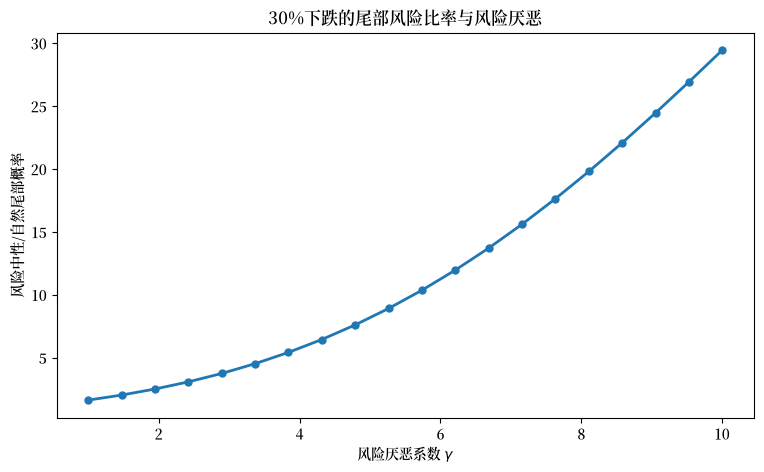

In [14]:
def tail_risk_ratio(γ, threshold, μ=0.08, σ=0.20, ρ=0.02, T=1.0):
    """风险中性/自然左尾概率。"""
    P_g, states_g = build_state_price_matrix(
        μ, σ, γ, ρ, T, n_states=41, n_σ=5)

    F_g, _, _, _ = recover_natural_distribution(P_g)

    mid_g = len(states_g) // 2

    f_nat_g = F_g[mid_g]
    f_rn_g = P_g[mid_g] / P_g[mid_g].sum()

    p_nat = float(np.sum(f_nat_g[states_g <= threshold]))
    p_rn = float(np.sum(f_rn_g[states_g <= threshold]))

    if p_nat < 1e-12:
        return np.nan
    return p_rn / p_nat


γs = np.linspace(1.0, 10.0, 20)
threshold_30 = np.log(0.70)
ratios = [tail_risk_ratio(g, threshold_30) for g in γs]

plt.figure(figsize=(9, 5))
plt.plot(γs, ratios, '-o', ms=5, lw=2)
plt.xlabel('风险厌恶系数 $\\gamma$')
plt.ylabel('风险中性/自然尾部概率')
plt.title('30%下跌的尾部风险比率与风险厌恶')
plt.show()

较高的风险厌恶系数 $\gamma$ 使定价核更陡峭：市场对坏状态收益每单位概率赋予更大的溢价。

风险中性概率纳入了这个溢价，因此在这个 CRRA 模拟中，风险中性崩盘概率随 $\gamma$ 上升得比恢复的自然崩盘概率更快。

恢复将市场估计的自然崩盘概率与附加于崩盘状态的定价核溢价分离开来。

```{solution-end}
```